# HÀNH TRÌNH SPEED DATING: TỪ KỲ VỌNG ĐẾN THỰC TẾ

## Chương 1: Sự hiếm hoi của một 'Match'
Trong hàng ngàn cuộc gặp gỡ, tỉ lệ hai người cùng đồng ý hẹn hò thực tế là bao nhiêu?

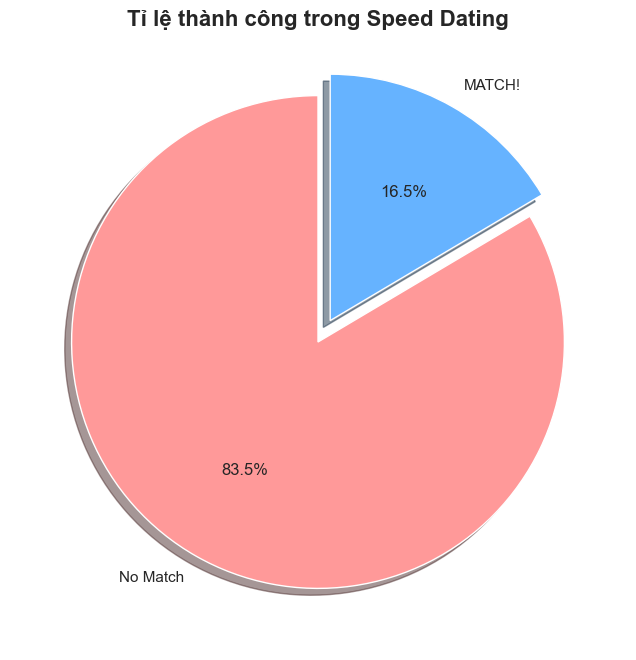

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
df = pd.read_csv('../Speed Dating Data.csv', encoding='latin1')

# 1. Pie Chart for Match Rate
match_data = df['match'].value_counts(normalize=True)
colors = ['#ff9999','#66b3ff']
plt.figure(figsize=(8, 8))
plt.pie(match_data, labels=['No Match', 'MATCH!'], autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=(0, 0.1), shadow=True)
plt.title('Tỉ lệ thành công trong Speed Dating', fontsize=16, fontweight='bold')
plt.show()

## Chương 2: Nghịch lý của sự lựa chọn (Choice Overload)
Liệu việc cho phép người tham gia gặp gỡ quá nhiều người có thực sự giúp họ dễ tìm thấy 'nửa kia' hơn?

/var/folders/1m/yr25jmsj1pzgbypyqwchhrv40000gn/T/ipykernel_97717/3648699007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Ít lựa chọn (<=10)', 'Nhiều lựa chọn (>20)'], y=ct_pct[1], palette='magma')


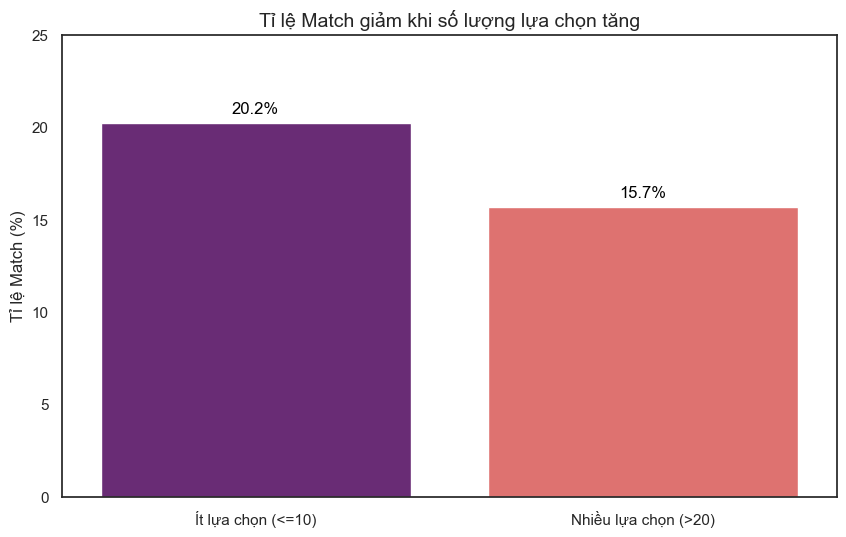

In [11]:
ct_pct = pd.crosstab(df['condtn'], df['match'], normalize='index') * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=['Ít lựa chọn (<=10)', 'Nhiều lựa chọn (>20)'], y=ct_pct[1], palette='magma')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 10), 
                textcoords='offset points')

plt.title('Tỉ lệ Match giảm khi số lượng lựa chọn tăng', fontsize=14)
plt.ylabel('Tỉ lệ Match (%)')
plt.ylim(0, 25)
plt.show()

## Chương 3: Những gì chúng ta nói vs. Những gì chúng ta làm
Khoảng cách giữa tiêu chí lý tưởng và quyết định thực tế tại bàn hẹn hò.

/var/folders/1m/yr25jmsj1pzgbypyqwchhrv40000gn/T/ipykernel_97717/3135280411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs, y=labels, palette='coolwarm')


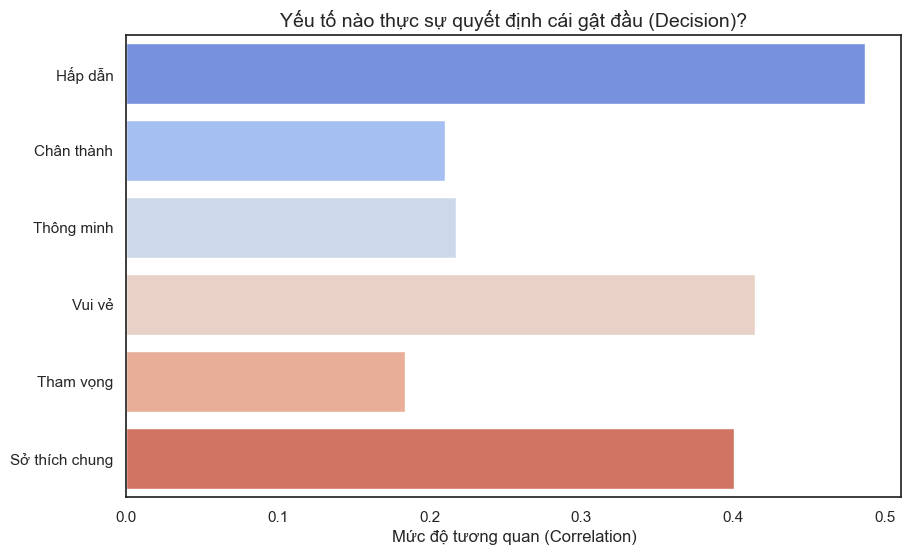

In [12]:
rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
labels = ['Hấp dẫn', 'Chân thành', 'Thông minh', 'Vui vẻ', 'Tham vọng', 'Sở thích chung']

corrs = df[rating_cols + ['dec']].corr()['dec'].drop('dec').values

plt.figure(figsize=(10, 6))
sns.barplot(x=corrs, y=labels, palette='coolwarm')
plt.title('Yếu tố nào thực sự quyết định cái gật đầu (Decision)?', fontsize=14)
plt.xlabel('Mức độ tương quan (Correlation)')
plt.show()

## Chương 4: Chân dung những người tham gia
Ai là người đang đi tìm kiếm tình yêu trong tập dữ liệu này?

/var/folders/1m/yr25jmsj1pzgbypyqwchhrv40000gn/T/ipykernel_97717/1849975834.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['race_label'] = df['race'].map(race_map)
/var/folders/1m/yr25jmsj1pzgbypyqwchhrv40000gn/T/ipykernel_97717/1849975834.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_counts.index, y=race_counts.values, palette='viridis', ax=ax2)


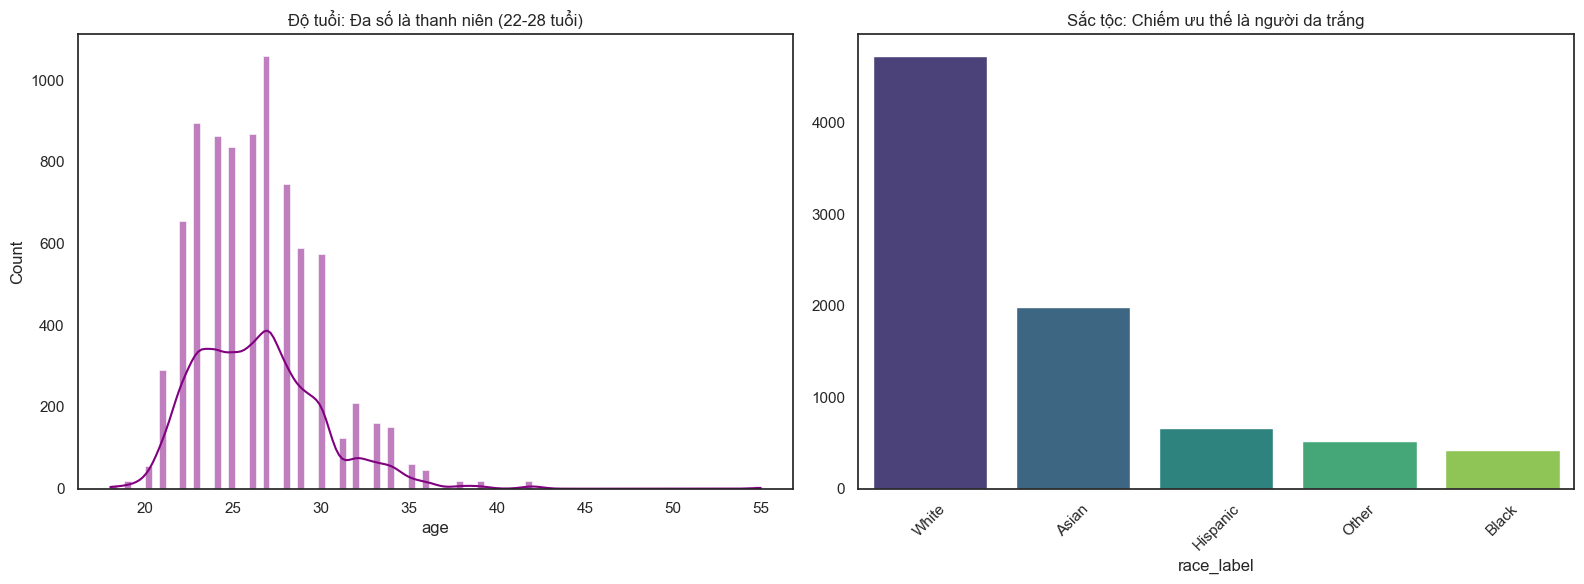

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['age'].dropna(), kde=True, color='purple', ax=ax1)
ax1.set_title('Độ tuổi: Đa số là thanh niên (22-28 tuổi)', fontsize=12)

race_map = {1: 'Black', 2: 'White', 3: 'Hispanic', 4: 'Asian', 5: 'Native', 6: 'Other'}
df['race_label'] = df['race'].map(race_map)
race_counts = df['race_label'].value_counts()

sns.barplot(x=race_counts.index, y=race_counts.values, palette='viridis', ax=ax2)
ax2.set_title('Sắc tộc: Chiếm ưu thế là người da trắng', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()